In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("india_insurance_claims_synthetic.csv")
df.shape

(15000, 18)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   claim_id           15000 non-null  object 
 1   claim_date         15000 non-null  object 
 2   claim_year         15000 non-null  int64  
 3   claim_month        15000 non-null  int64  
 4   insurer            15000 non-null  object 
 5   state              15000 non-null  object 
 6   vehicle_type       15000 non-null  object 
 7   vehicle_age_years  15000 non-null  int64  
 8   policy_age_months  15000 non-null  int64  
 9   incident_type      15000 non-null  object 
 10  garage_type        15000 non-null  object 
 11  claim_amount_inr   15000 non-null  float64
 12  claims_last_12m    15000 non-null  int64  
 13  days_to_report     15000 non-null  int64  
 14  surveyor_flag      15000 non-null  int64  
 15  india_cpi          15000 non-null  float64
 16  india_gdp_growth   150

In [4]:
df.describe()

,claim_year,claim_month,vehicle_age_years,policy_age_months,claim_amount_inr,claims_last_12m,days_to_report,surveyor_flag,india_cpi,india_gdp_growth,fraud_flag
count,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2021.061067,6.569400,4.010667,30.250667,1.276202e+05,0.302867,5.439000,0.573133,4.911261,5.881475,0.103733
std,3.400565,3.464349,4.303509,17.092282,1.550778e+05,0.557219,5.873799,0.494639,1.082787,3.728666,0.304924
min,2015.000000,1.000000,0.000000,1.000000,5.000000e+03,0.000000,0.000000,0.000000,2.490000,-5.830000,0.000000
25%,2018.000000,4.000000,1.000000,15.000000,4.977854e+04,0.000000,1.000000,0.000000,4.500000,6.100000,0.000000
50%,2021.000000,7.000000,3.000000,30.000000,8.600104e+04,0.000000,4.000000,1.000000,4.860000,6.500000,0.000000
75%,2024.000000,10.000000,6.000000,45.000000,1.426209e+05,1.000000,8.000000,1.000000,5.650000,8.000000,0.000000
max,2026.000000,12.000000,20.000000,59.000000,1.500000e+06,5.000000,58.000000,1.000000,6.700000,9.050000,1.000000


In [5]:
df['fraud_flag'].value_counts(normalize=True)

fraud_flag
0    0.896267
1    0.103733
Name: proportion, dtype: float64

(array([2.125e+03, 3.262e+03, 2.894e+03, 2.031e+03, 1.420e+03, 9.260e+02,
        5.690e+02, 3.430e+02, 2.230e+02, 1.920e+02, 1.230e+02, 1.060e+02,
        7.400e+01, 6.600e+01, 6.500e+01, 4.600e+01, 4.500e+01, 4.500e+01,
        3.900e+01, 3.400e+01, 3.500e+01, 2.800e+01, 3.100e+01, 2.700e+01,
        1.200e+01, 2.600e+01, 2.500e+01, 1.900e+01, 1.500e+01, 1.300e+01,
        1.500e+01, 2.000e+01, 7.000e+00, 1.000e+01, 1.000e+01, 9.000e+00,
        1.000e+01, 7.000e+00, 1.000e+01, 2.000e+00, 6.000e+00, 2.000e+00,
        5.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 2.200e+01]),
 array([   5000.,   34900.,   64800.,   94700.,  124600.,  154500.,
         184400.,  214300.,  244200.,  274100.,  304000.,  333900.,
         363800.,  393700.,  423600.,  453500.,  483400.,  513300.,
         543200.,  573100.,  603000.,  632900.,  662800.,  692700.,
         722600.,  752500.,  782400.,  812300.,  842200.,  872100.,
         902000.,  931900.,  961800.

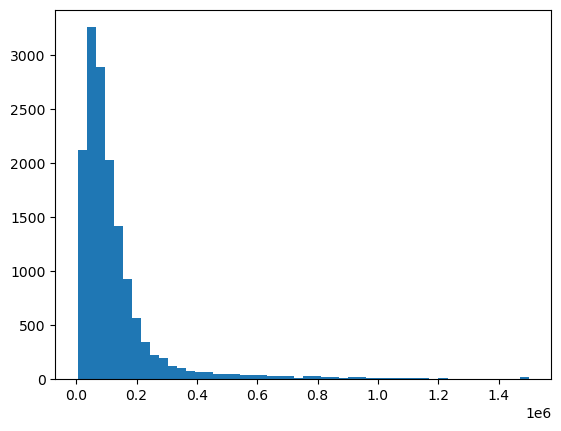

In [6]:
plt.hist(df['claim_amount_inr'], bins=50)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c0d3625450>,
 'caps': [<matplotlib.lines.Line2D at 0x1c0d36256d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c0d3625310>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0d3625950>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c0d3625a90>],
 'means': []}

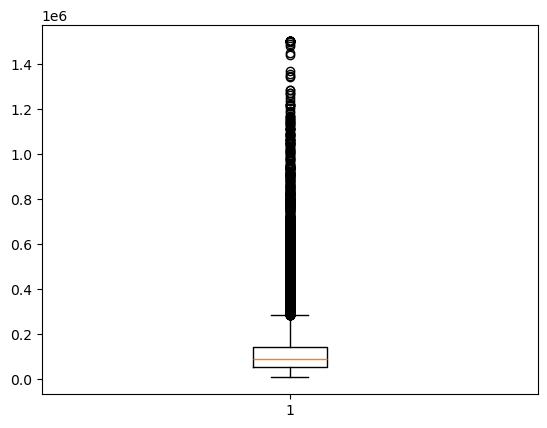

In [7]:
plt.boxplot(df['claim_amount_inr'])

In [8]:
df.groupby('fraud_flag')['claim_amount_inr'].median()

fraud_flag
0     78867.145
1    353808.580
Name: claim_amount_inr, dtype: float64

In [9]:
df.groupby('fraud_flag')['claim_amount_inr'].mean()

fraud_flag
0     92296.410300
1    432821.427481
Name: claim_amount_inr, dtype: float64

In [10]:
pd.crosstab(df['incident_type'],
            df['fraud_flag'],
            normalize='index')

fraud_flag,0,1
incident_type,,
Collision,0.922027,0.077973
Fire,0.844122,0.155878
Natural Disaster,0.912257,0.087743
Theft,0.847518,0.152482
Vandalism,0.920131,0.079869


In [11]:
pd.crosstab(df['garage_type'],
            df['fraud_flag'],
            normalize='index')

fraud_flag,0,1
garage_type,,
Cash Settlement,0.803804,0.196196
Network Garage,0.920290,0.079710
Non-Network Garage,0.917820,0.082180


In [12]:
pd.crosstab(df['vehicle_type'],
            df['fraud_flag'],
            normalize='index')

fraud_flag,0,1
vehicle_type,,
Commercial Vehicle,0.856440,0.143560
Private Car,0.901807,0.098193
Two-Wheeler,0.904857,0.095143


In [13]:
yearly = df.groupby('claim_year').agg({
    'india_cpi':'mean',
    'fraud_flag':'mean'
})
yearly

,india_cpi,fraud_flag
claim_year,,
2015,4.91,0.083700
2016,4.94,0.093939
2017,2.49,0.084211
2018,4.86,0.097385
2019,3.72,0.084996
2020,6.62,0.175994
2021,5.13,0.102368
2022,6.70,0.118819
2023,5.65,0.100652


In [14]:
yearly = df.groupby('claim_year').agg({
    'india_gdp_growth':'mean',
    'fraud_flag':'mean'
})
yearly

,india_gdp_growth,fraud_flag
claim_year,,
2015,8.00,0.083700
2016,8.26,0.093939
2017,6.80,0.084211
2018,6.45,0.097385
2019,3.87,0.084996
2020,-5.83,0.175994
2021,9.05,0.102368
2022,7.24,0.118819
2023,8.20,0.100652


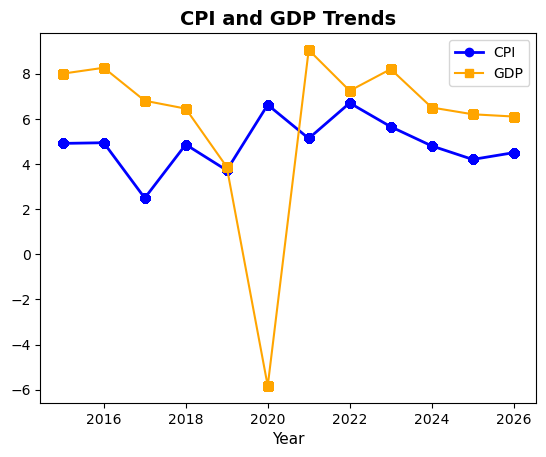

In [15]:
plt.plot(df['claim_year'], df['india_cpi'], label='CPI', color='blue', marker='o', linewidth=2)
plt.plot(df['claim_year'],df['india_gdp_growth'], label='GDP', color='orange', linestyle='-', marker='s')
plt.title('CPI and GDP Trends', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.legend()
plt.show()